# COVID-19 Global Trends Analysis

This project explores global COVID-19 case data to understand how the pandemic 
spread over time, which countries were most affected, and how fatality rates 
varied by region.

**Dataset:** COVID-19 Clean Complete dataset (Confirmed, Deaths, Recovered by 
country and date)

## 1. Import Libraries

In [1]:
# pandas: for loading and working with the dataset (tables/dataframes)
import pandas as pd
import numpy as np

# matplotlib: for creating charts
import matplotlib.pyplot as plt

# seaborn: makes charts look nicer and adds extra chart types (like heatmaps)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load and Inspect the Data

In [2]:
# Load the CSV file into a dataframe
df = pd.read_csv('covid_19_clean_complete.csv')

# Look at the first 5 rows to see what the data looks like
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [3]:
# Check the shape: (number of rows, number of columns)
df.shape

(49068, 10)

In [4]:
# Check data types and see if any columns have missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
# Count missing values per column, to confirm what info() showed
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Observations:**
- The dataset has 49068 rows and 10 columns
- `Province/State` has 34404 of missing values, since not every country reports state-level data
- `Date` is currently stored as text, not as a real date
- No duplicated values

## 3. Clean the Data

In [8]:
# Drop Province/State since we're analyzing at the country level, not state level
df = df.drop(columns=['Province/State'])

In [9]:
# Convert Date from text to an actual datetime type
# This lets pandas understand it as a real calendar date, so we can sort, 
# filter, and plot it correctly over time
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
# Confirm the changes worked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


**Observations:**
- Dropped `Province/State` — not needed for country-level analysis
- `Date` is now a proper datetime type, confirmed by `df.info()`
- Dataset is now clean and ready for analysis: 49068 rows, 10 columns

## 4. Analysis Questions

This analysis aims to answer the following questions:

1. How did global confirmed cases, deaths, and recoveries change over time?
2. Which countries had the highest numbers in each category?
   - Top 10 countries by confirmed cases
   - Top 10 countries by deaths
   - Top 10 countries by recoveries
3. Which countries had the highest COVID-19 fatality rate (deaths ÷ confirmed)?
4. How did case numbers compare across WHO regions?
5. Is there a relationship between confirmed cases, deaths, and recoveries?

In [14]:
# Find the earliest and latest date in the dataset
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

Start date: 2020-01-22 00:00:00
End date: 2020-07-27 00:00:00


In [15]:
# Calculate how many days the dataset covers
(df['Date'].max() - df['Date'].min()).days

187

The dataset covers the period from 2020-01-22 to 2020-07-27, spanning 
approximately 187 days of the pandemic's early progression.

## 5. Analysis

### Question 1: Global Trend Over Time

In [11]:
# Group by Date and sum across all countries to get global daily totals
global_trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

# Preview the result
global_trend.head()

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52


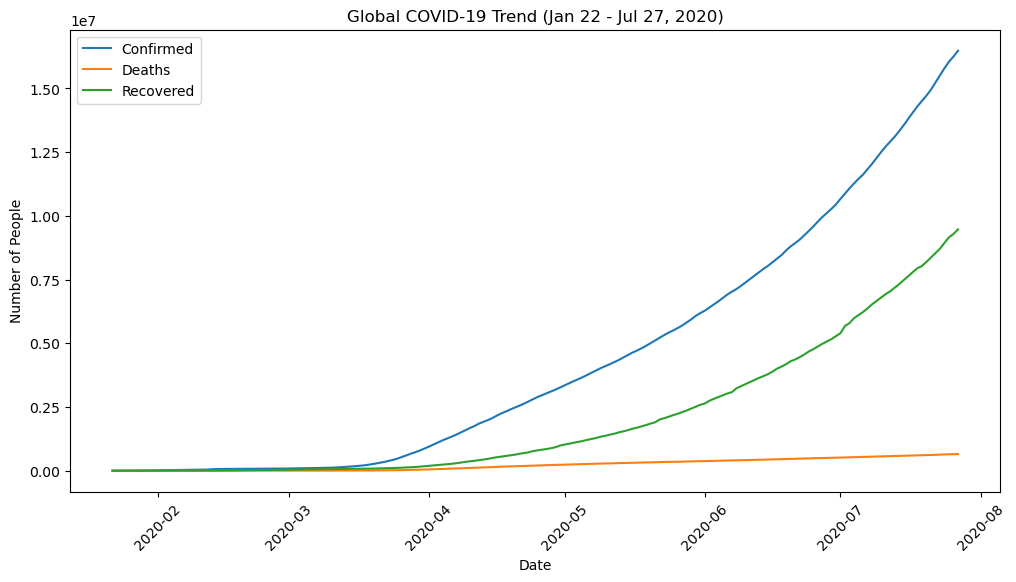

In [16]:
# Set a chart size so it's readable
plt.figure(figsize=(12, 6))

# Plot each metric as its own line over time
plt.plot(global_trend['Date'], global_trend['Confirmed'], label='Confirmed')
plt.plot(global_trend['Date'], global_trend['Deaths'], label='Deaths')
plt.plot(global_trend['Date'], global_trend['Recovered'], label='Recovered')

# Add labels and title so anyone viewing this chart understands it instantly
plt.title('Global COVID-19 Trend (Jan 22 - Jul 27, 2020)')
plt.xlabel('Date')
plt.ylabel('Number of People')
plt.legend()
plt.xticks(rotation=45)

# Show the chart
plt.show()

**Observations:**
- Confirmed cases remained low until around March 2020, then grew sharply, 
  reflecting the early exponential spread of the pandemic globally.
- Deaths remained comparatively low in absolute numbers throughout the period, 
  though this does not account for fatality rate, which is examined separately.
- Recovered cases grew alongside confirmed cases but at a slightly slower pace, 
  indicating a growing number of active cases over time.

### Question 2: Top 10 Countries by Confirmed, Deaths, and Recoveries

In [17]:
# Get only the rows for the most recent date, since Confirmed/Deaths/Recovered 
# are cumulative totals — we want each country's latest total, not a sum across all dates
latest_date = df['Date'].max()
latest = df[df['Date'] == latest_date]

# Preview it
latest.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


In [ ]:
# Group by country (some countries have multiple rows per date due to states/provinces)
# and sum, then sort to get the top 10 by confirmed cases
top_confirmed = latest.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
top_confirmed

Country/Region
US                4290259
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     301708
Iran               293606
Name: Confirmed, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'US'),
  Text(1, 0, 'Brazil'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Russia'),
  Text(4, 0, 'South Africa'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'Peru'),
  Text(7, 0, 'Chile'),
  Text(8, 0, 'United Kingdom'),
  Text(9, 0, 'Iran')])

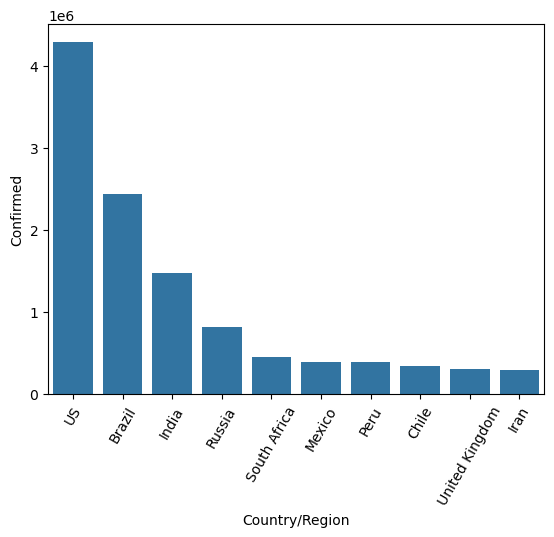

In [21]:
sns.barplot(top_confirmed)
plt.xticks(rotation=60)

**Observations:**
- The United States, Brazil, and India had the highest confirmed case counts, 
  reflecting large populations combined with widespread community transmission.
- Several Latin American countries (Brazil, Mexico, Peru, Chile) appear in the 
  top 10, indicating the region was heavily affected during this period.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'US'),
  Text(1, 0, 'Brazil'),
  Text(2, 0, 'United Kingdom'),
  Text(3, 0, 'Mexico'),
  Text(4, 0, 'Italy'),
  Text(5, 0, 'India'),
  Text(6, 0, 'France'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'Peru'),
  Text(9, 0, 'Iran')])

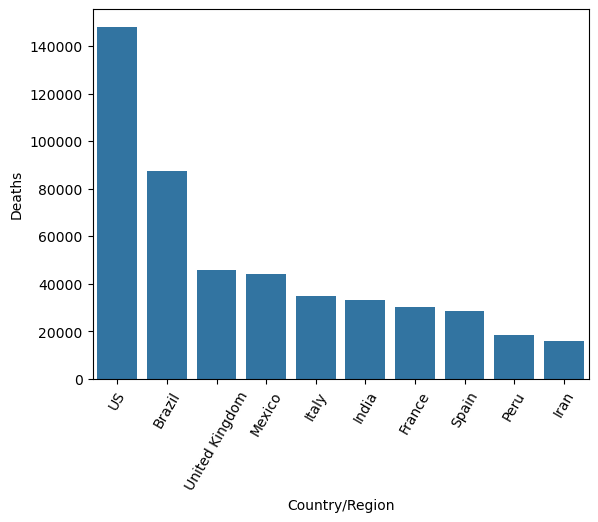

In [26]:
# Same approach, but for Deaths
top_deaths = latest.groupby('Country/Region')['Deaths'].sum().sort_values(ascending=False).head(10)
sns.barplot(top_deaths)
plt.xticks(rotation=60)

**Observations:**
- The US, Brazil, and the UK had the highest death counts overall.
- Several European countries (UK, Italy, France, Spain) appear here despite 
  not all being in the top 10 for confirmed cases, suggesting higher fatality 
  in these countries relative to their case counts.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'US'),
  Text(2, 0, 'India'),
  Text(3, 0, 'Russia'),
  Text(4, 0, 'Chile'),
  Text(5, 0, 'Mexico'),
  Text(6, 0, 'South Africa'),
  Text(7, 0, 'Peru'),
  Text(8, 0, 'Iran'),
  Text(9, 0, 'Pakistan')])

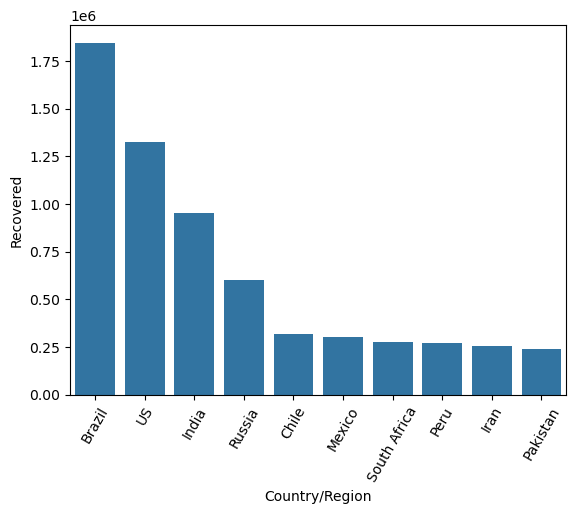

In [27]:
# Same approach, but for Recovered
top_recovered = latest.groupby('Country/Region')['Recovered'].sum().sort_values(ascending=False).head(10)
sns.barplot(top_recovered)
plt.xticks(rotation=60)

**Observations:**
- Brazil, the US, and India had the highest recovery counts, consistent with 
  them also having the highest confirmed case counts.
- Pakistan appears in the top 10 for recoveries despite not appearing in the 
  top 10 for confirmed cases or deaths — suggesting a comparatively high 
  recovery rate relative to its case count.

### Question 3: Fatality Rate by Country

In [30]:
# Group by country using the latest date's data
country_totals = latest.groupby('Country/Region')[['Confirmed', 'Deaths']].sum()

# Only keep countries with a meaningful number of cases (e.g. at least 1000)
# so tiny outbreaks don't distort the fatality rate with misleading percentages
country_totals = country_totals[country_totals['Confirmed'] >= 1000]

# Calculate fatality rate as a percentage
country_totals['Fatality_Rate_%'] = (country_totals['Deaths'] / country_totals['Confirmed']) * 100

# Sort and get top 10
top_fatality = country_totals.sort_values('Fatality_Rate_%', ascending=False).head(10)
top_fatality


,Confirmed,Deaths,Fatality_Rate_%
Country/Region,,,
Yemen,1691,483,28.562980
United Kingdom,301708,45844,15.194824
Belgium,66428,9822,14.785934
Italy,246286,35112,14.256596
France,220352,30212,13.710790
Hungary,4448,596,13.399281
Netherlands,53413,6160,11.532773
Mexico,395489,44022,11.131030
Spain,272421,28432,10.436787


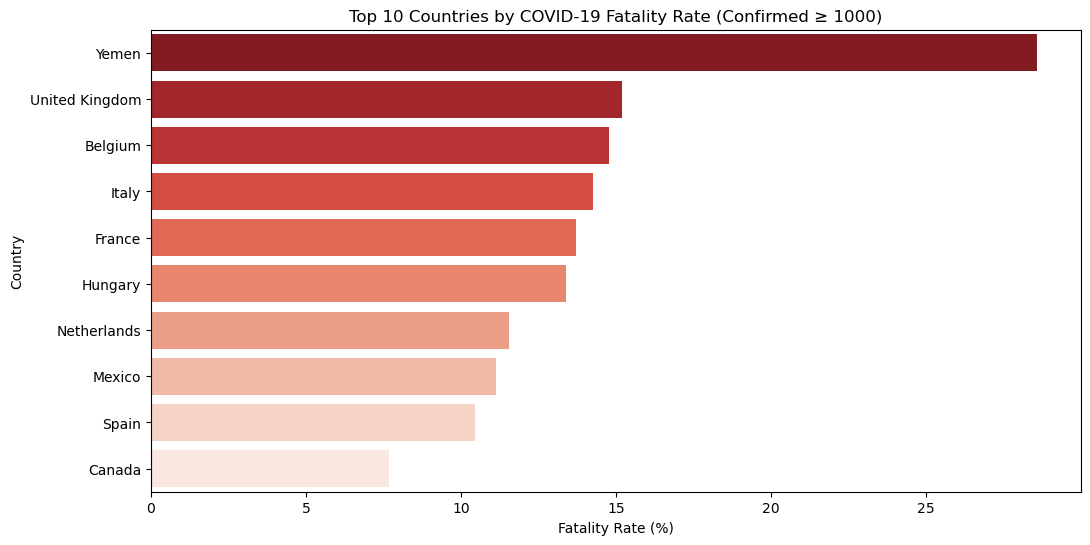

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_fatality['Fatality_Rate_%'], y=top_fatality.index, palette='Reds_r')
plt.title('Top 10 Countries by COVID-19 Fatality Rate (Confirmed ≥ 1000)')
plt.xlabel('Fatality Rate (%)')
plt.ylabel('Country')
plt.show()

**Observations:**
- Yemen had by far the highest fatality rate (28.6%), notably higher than 
  any other country — likely linked to limited healthcare capacity rather 
  than case volume alone.
- Several Western European countries (UK, Belgium, Italy, France) appear here 
  despite not always topping the confirmed cases list — suggesting these 
  countries had proportionally more severe outcomes among reported cases, 
  possibly due to earlier waves, older populations, or testing limitations 
  undercounting mild cases.
- Notably, the US, Brazil, and India — all in the top 10 for confirmed cases 
  — do NOT appear here, meaning high case volume didn't necessarily translate 
  to high fatality rate.

### Question 4: Comparison Across WHO Regions

In [32]:
# Group by WHO Region using the latest date's data
region_totals = latest.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Sort by Confirmed so the chart reads highest to lowest
region_totals = region_totals.sort_values('Confirmed', ascending=False)
region_totals

,Confirmed,Deaths,Recovered
WHO Region,,,
Americas,8839286,342732,4468616
Europe,3299523,211144,1993723
South-East Asia,1835297,41349,1156933
Eastern Mediterranean,1490744,38339,1201400
Africa,723207,12223,440645
Western Pacific,292428,8249,206770


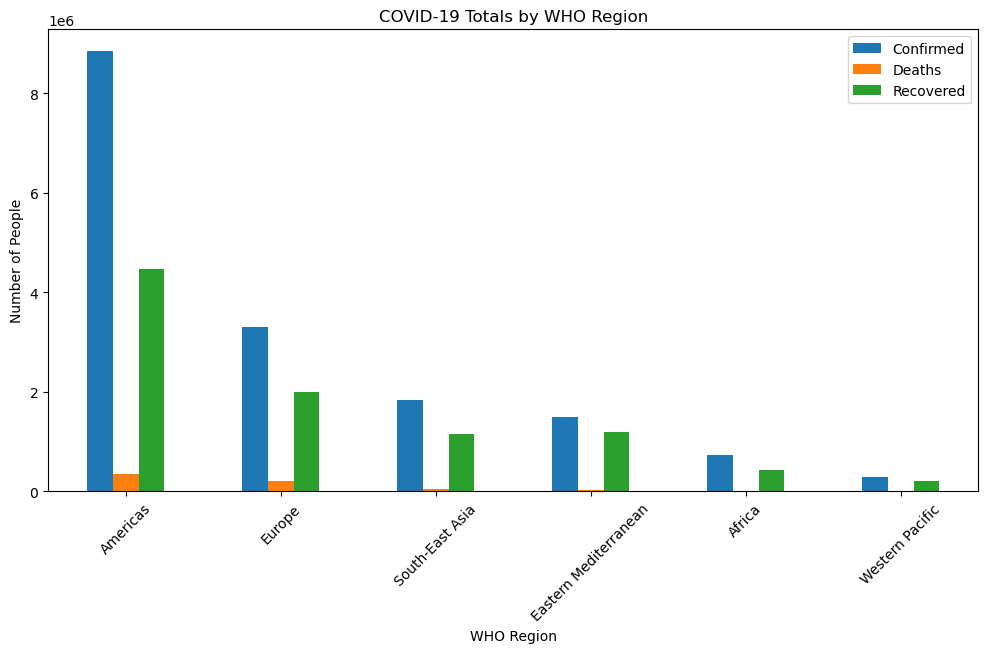

In [35]:
region_totals.plot(kind='bar', figsize=(12, 6))
plt.title('COVID-19 Totals by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.show()

**Observations:**
- The Americas had by far the highest number of confirmed cases, deaths, and 
  recoveries, consistent with the US and Brazil dominating the country-level 
  totals seen earlier.
- Europe followed as the second most affected region, aligning with several 
  European countries appearing in both the confirmed cases and fatality rate 
  top 10 lists.
- Africa and the Western Pacific had comparatively low totals during this 
  period, though this may partly reflect lower testing capacity rather than 
  lower actual spread — a limitation worth noting rather than taken at face 
  value.

### Question 5: Relationship Between Confirmed, Deaths, and Recovered

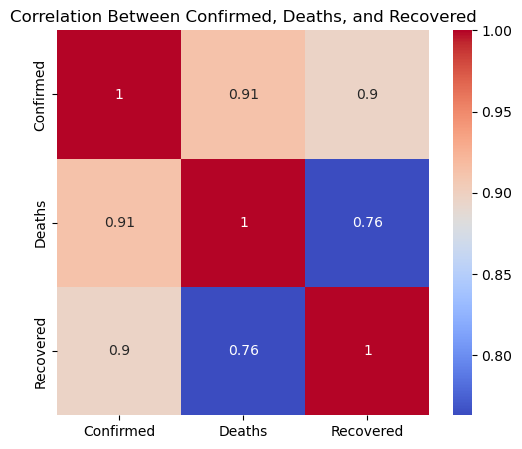

In [38]:
# Calculate correlation between the three numeric columns
correlation = df[['Confirmed', 'Deaths', 'Recovered']].corr()

# Plot as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Between Confirmed, Deaths, and Recovered')
plt.show()

**Observations:**
- Confirmed and Deaths are strongly correlated (0.91), meaning countries with 
  more confirmed cases generally also had more deaths — as expected.
- Confirmed and Recovered are also strongly correlated (0.90), showing 
  recovery counts scale with case counts in a similar way.
- Deaths and Recovered have a slightly weaker correlation (0.76) compared to 
  the other two, suggesting the relationship between how many people died 
  versus recovered varies more by country — likely reflecting differences in 
  healthcare quality, testing, and reporting between countries, rather than 
  being purely a function of case volume.

## 6. Conclusion

This analysis examined global COVID-19 data from January 22 to July 27, 2020 
(187 days). Key findings:

- Global confirmed cases grew exponentially starting around March 2020.
- The US, Brazil, and India had the highest case counts, but did not have the 
  highest fatality rates — Yemen and several Western European countries did, 
  highlighting that case volume alone doesn't determine severity.
- The Americas and Europe were the most affected regions overall, though lower 
  numbers in Africa and the Western Pacific may partly reflect limited testing 
  rather than lower actual spread.
- Confirmed cases were strongly correlated with both deaths and recoveries, 
  while the death-recovery relationship varied more — likely due to 
  differences in healthcare systems across countries.